In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/mental_health_tech_ml.csv")

df_ml.head()

,Age,self_employed,family_history,treatment,remote_work,tech_company,obs_consequence,Age__missing,Gender__missing,state__missing,self_employed__missing,work_interfere__missing,work_interfere_Never,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,Gender_male,Country_Austria,"Country_Bahamas, The",Country_Belgium,Country_Bosnia and Herzegovina,Country_Brazil,Country_Bulgaria,Country_Canada,Country_China,Country_Colombia,Country_Costa Rica,Country_Croatia,Country_Czech Republic,Country_Denmark,Country_Finland,Country_France,Country_Georgia,Country_Germany,Country_Greece,Country_Hungary,Country_India,Country_Ireland,Country_Israel,Country_Italy,Country_Japan,Country_Latvia,Country_Mexico,Country_Moldova,Country_Netherlands,Country_New Zealand,Country_Nigeria,Country_Norway,Country_Philippines,Country_Poland,Country_Portugal,Country_Romania,Country_Russia,Country_Singapore,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_United Kingdom,Country_United States,Country_Uruguay,Country_Zimbabwe,state_AZ,state_CA,state_CO,state_CT,state_DC,state_FL,state_GA,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_NC,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37.0,0.0,0,1,0,1,0,0,0,0,1,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,True,False,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,True,True,False,False,False,False,True
1,44.0,0.0,0,0,0,0,0,0,0,0,1,0,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False
2,32.0,0.0,0,0,0,1,0,0,0,1,1,0,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [2]:
# Target variable: work interference + treatment
# Exclude rows where the original target-defining variables were missing
df = df_ml.copy()

# Keep only rows with observed work_interfere and treatment
if "work_interfere__missing" in df.columns:
    df = df[df["work_interfere__missing"] == 0].copy()

if "treatment__missing" in df.columns:
    df = df[df["treatment__missing"] == 0].copy()

# Create binary work interference variable
# 0 = Never
# 1 = Rarely / Sometimes / Often
df["work_interfere_binary"] = (
    df[[
        "work_interfere_Rarely",
        "work_interfere_Sometimes",
        "work_interfere_Often"
    ]].sum(axis=1) > 0
).astype(int)

# Create combined target variable:
# 0 = no interference
# 1 = interference but no treatment
# 2 = interference + treatment
df["combined_target"] = np.select(
    [
        df["work_interfere_Never"] == 1,
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 0),
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 1),
    ],
    [0, 1, 2],
    default=np.nan
)

# Drop any rows that still do not have a valid target
df = df.dropna(subset=["combined_target"]).copy()
df["combined_target"] = df["combined_target"].astype(int)

# Define predictors and target
# Remove:
# - target variable
# - target-defining variables (to avoid leakage)
# - missingness indicators for target-defining variables
X = df.drop(columns=[
    "combined_target",
    "treatment",
    "work_interfere_Never",
    "work_interfere_Rarely",
    "work_interfere_Sometimes",
    "work_interfere_Often",
    "work_interfere__missing",
    "work_interfere_binary",
    "treatment__missing"
], errors="ignore")

y = df["combined_target"]

# Check final class distribution
print(y.value_counts())
print(y.value_counts(normalize=True))
print(X.shape, y.shape)

combined_target
2    603
0    213
1    179
Name: count, dtype: int64
combined_target
2    0.606030
0    0.214070
1    0.179899
Name: proportion, dtype: float64
(995, 135) (995,)


In [3]:
# Should be 0
print(df["combined_target"].isna().sum())

# Sanity check: every row must belong to exactly one class
print(df["combined_target"].value_counts().sum(), len(df))

0
995 995


In [3]:
# Result means:
# 21.4% employees have no work interference (class 0), meaning they do not experience mental health issues that interfere with work.
# 60% employees have work interference and seek treatment (class 2)
# 35% employees experience work interference but do not seek treatment (class 1)
df["combined_target"].value_counts(normalize=True)

combined_target
2    0.606030
0    0.214070
1    0.179899
Name: proportion, dtype: float64

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)



              precision    recall  f1-score   support

           0       0.41      0.60      0.49        43
           1       0.34      0.44      0.39        36
           2       0.83      0.62      0.71       120

    accuracy                           0.58       199
   macro avg       0.53      0.56      0.53       199
weighted avg       0.65      0.58      0.60       199

Macro F1: 0.5280807259008046
Weighted F1: 0.6027634886932391


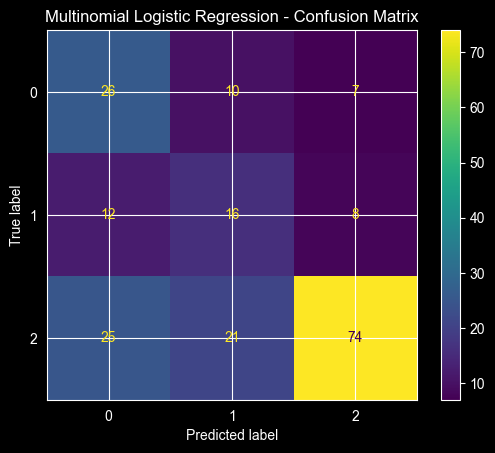

In [5]:
# Evaluation
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.43      0.51      0.47        43
           1       0.40      0.17      0.24        36
           2       0.74      0.82      0.78       120

    accuracy                           0.64       199
   macro avg       0.53      0.50      0.50       199
weighted avg       0.61      0.64      0.62       199

Random Forest Macro F1: 0.49532930656073715
Random Forest Weighted F1: 0.6156346295880556


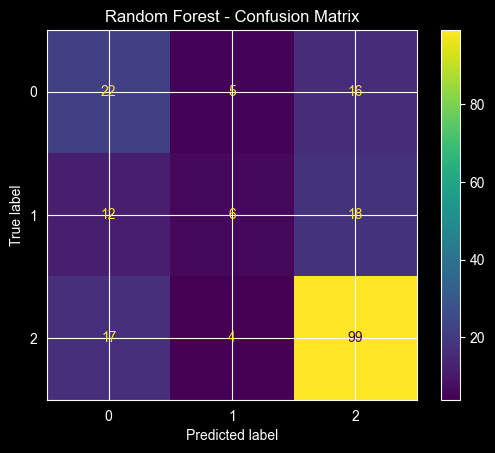

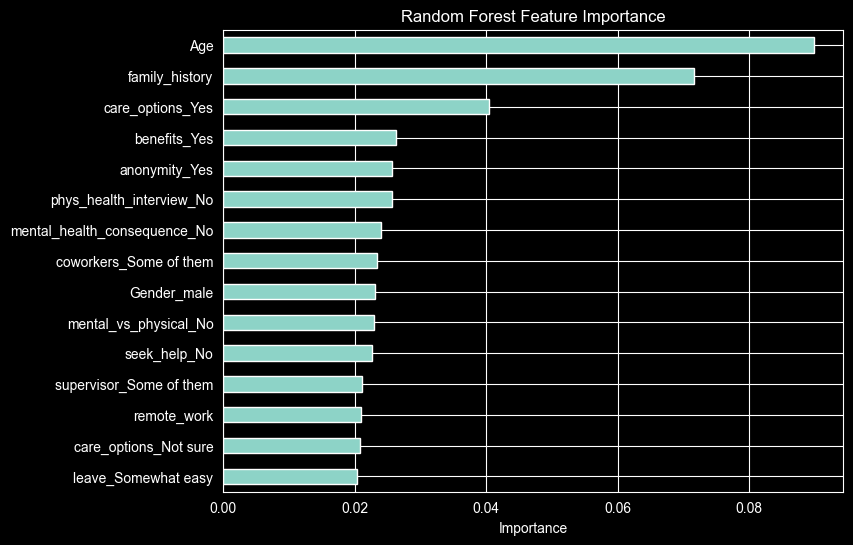

In [7]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print(classification_report(y_test, y_pred_rf))

macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Macro F1:", macro_f1_rf)
print("Random Forest Weighted F1:", weighted_f1_rf)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

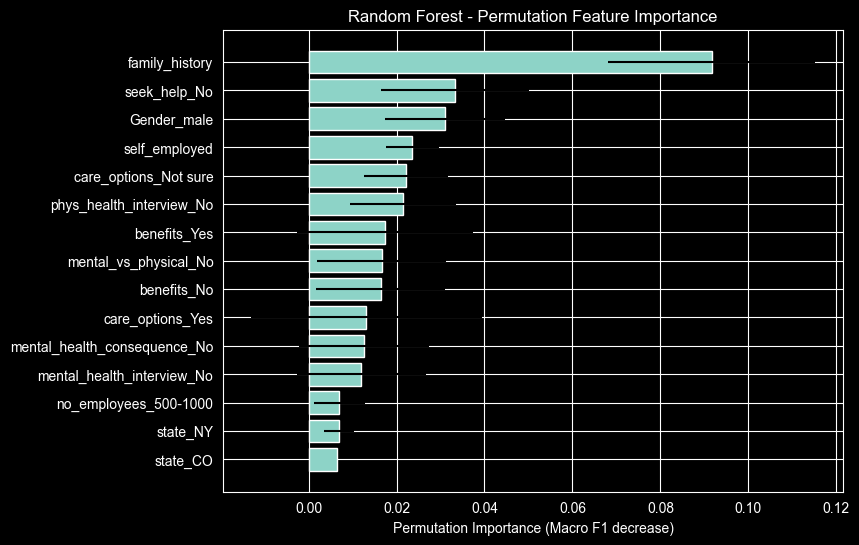

In [8]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_df.head(15)

top_features = perm_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Random Forest - Permutation Feature Importance")
plt.show()

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",   # multiclass probabilities
    num_class=3,                  # classes: 0, 1, 2
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.50      0.35      0.41        43
           1       0.35      0.17      0.23        36
           2       0.68      0.87      0.76       120

    accuracy                           0.63       199
   macro avg       0.51      0.46      0.47       199
weighted avg       0.58      0.63      0.59       199

XGBoost Macro F1: 0.4673599602673843
XGBoost Weighted F1: 0.590888855051717


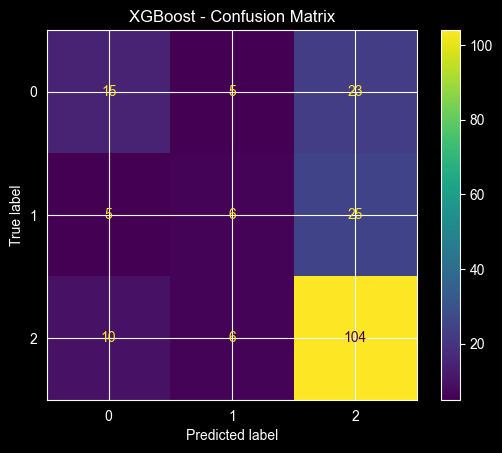

In [10]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_xgb))

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Macro F1:", macro_f1_xgb)
print("XGBoost Weighted F1:", weighted_f1_xgb)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

family_history                   0.044005
care_options_Yes                 0.023104
state_GA                         0.019341
Gender_male                      0.018179
anonymity_Yes                    0.017844
leave_Very difficult             0.017807
benefits_Yes                     0.016393
Country_United States            0.016290
no_employees_500-1000            0.016098
state_PA                         0.015809
phys_health_interview_Yes        0.015647
state__missing                   0.014960
leave_Somewhat difficult         0.014619
mental_health_consequence_Yes    0.014424
state_MI                         0.014154
dtype: float32


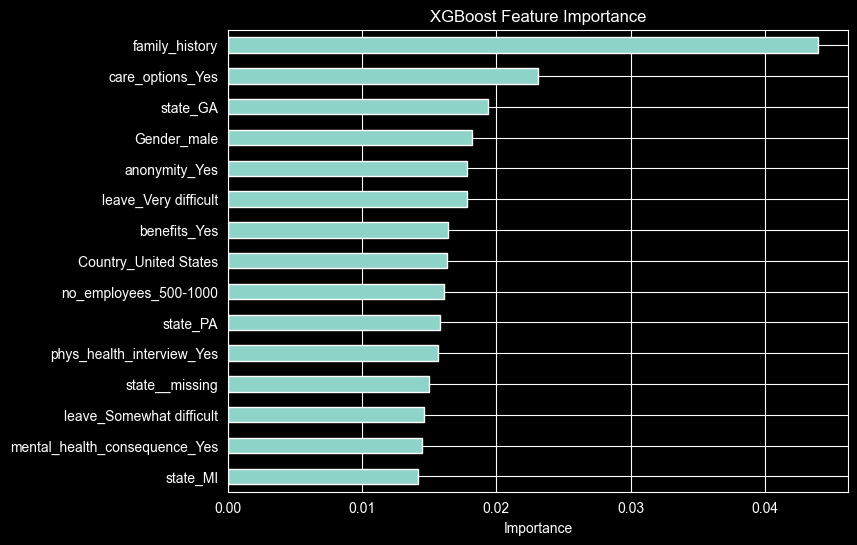

In [11]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

D:\Diana\Anul III\BachelorArbeit\WellBeingModelling\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                           feature  importance_mean  importance_std
2                   family_history         0.073063        0.021368
113                   seek_help_No         0.034374        0.014347
0                              Age         0.023737        0.017950
10                     Gender_male         0.022945        0.018458
129     mental_health_interview_No         0.021947        0.008371
110               care_options_Yes         0.019321        0.013689
122  mental_health_consequence_Yes         0.018661        0.010260
107                    benefits_No         0.017049        0.014664
106    no_employees_More than 1000         0.017035        0.008578
119           leave_Very difficult         0.012429        0.011051
112           wellness_program_Yes         0.011676        0.006943
131       phys_health_interview_No         0.011549        0.009618
109          care_options_Not sure         0.010473        0.009379
3                      remote_work         0.010

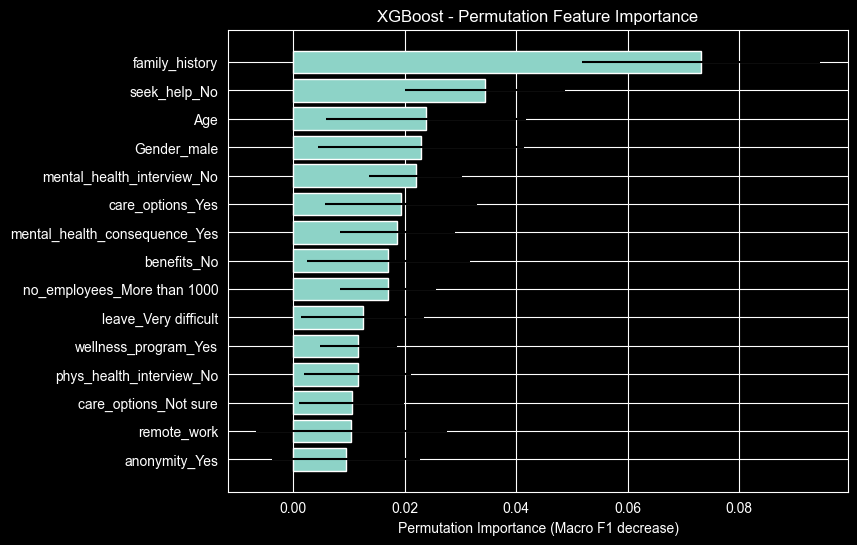

In [12]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_xgb_df.head(15))

top_features = perm_xgb_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("XGBoost - Permutation Feature Importance")
plt.show()

In [14]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,                # prevents overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.35      0.67      0.46        43
           1       0.18      0.22      0.20        36
           2       0.82      0.48      0.61       120

    accuracy                           0.48       199
   macro avg       0.45      0.46      0.42       199
weighted avg       0.60      0.48      0.50       199

Decision Tree Macro F1: 0.42172605581564276
Decision Tree Weighted F1: 0.5014288595808761


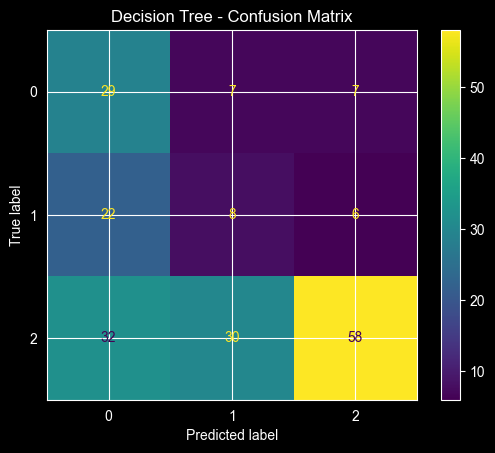

In [15]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_tree))

macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")
weighted_f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("Decision Tree Macro F1:", macro_f1_tree)
print("Decision Tree Weighted F1:", weighted_f1_tree)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

family_history                  0.200138
care_options_Yes                0.108540
Country_United States           0.097480
phys_health_interview_Yes       0.085766
mental_health_consequence_No    0.042047
no_employees_26-100             0.041540
leave_Very difficult            0.041265
care_options_Not sure           0.035751
wellness_program_Yes            0.029432
obs_consequence                 0.027037
Age                             0.024235
anonymity_Yes                   0.022061
no_employees_More than 1000     0.022048
benefits_Yes                    0.021253
leave_Somewhat difficult        0.021143
dtype: float64


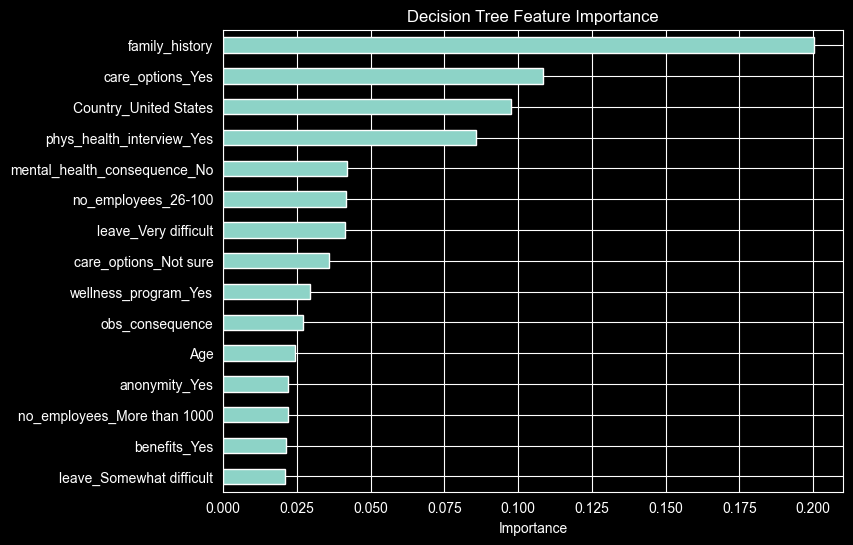

In [16]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(tree_importance.head(15))
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

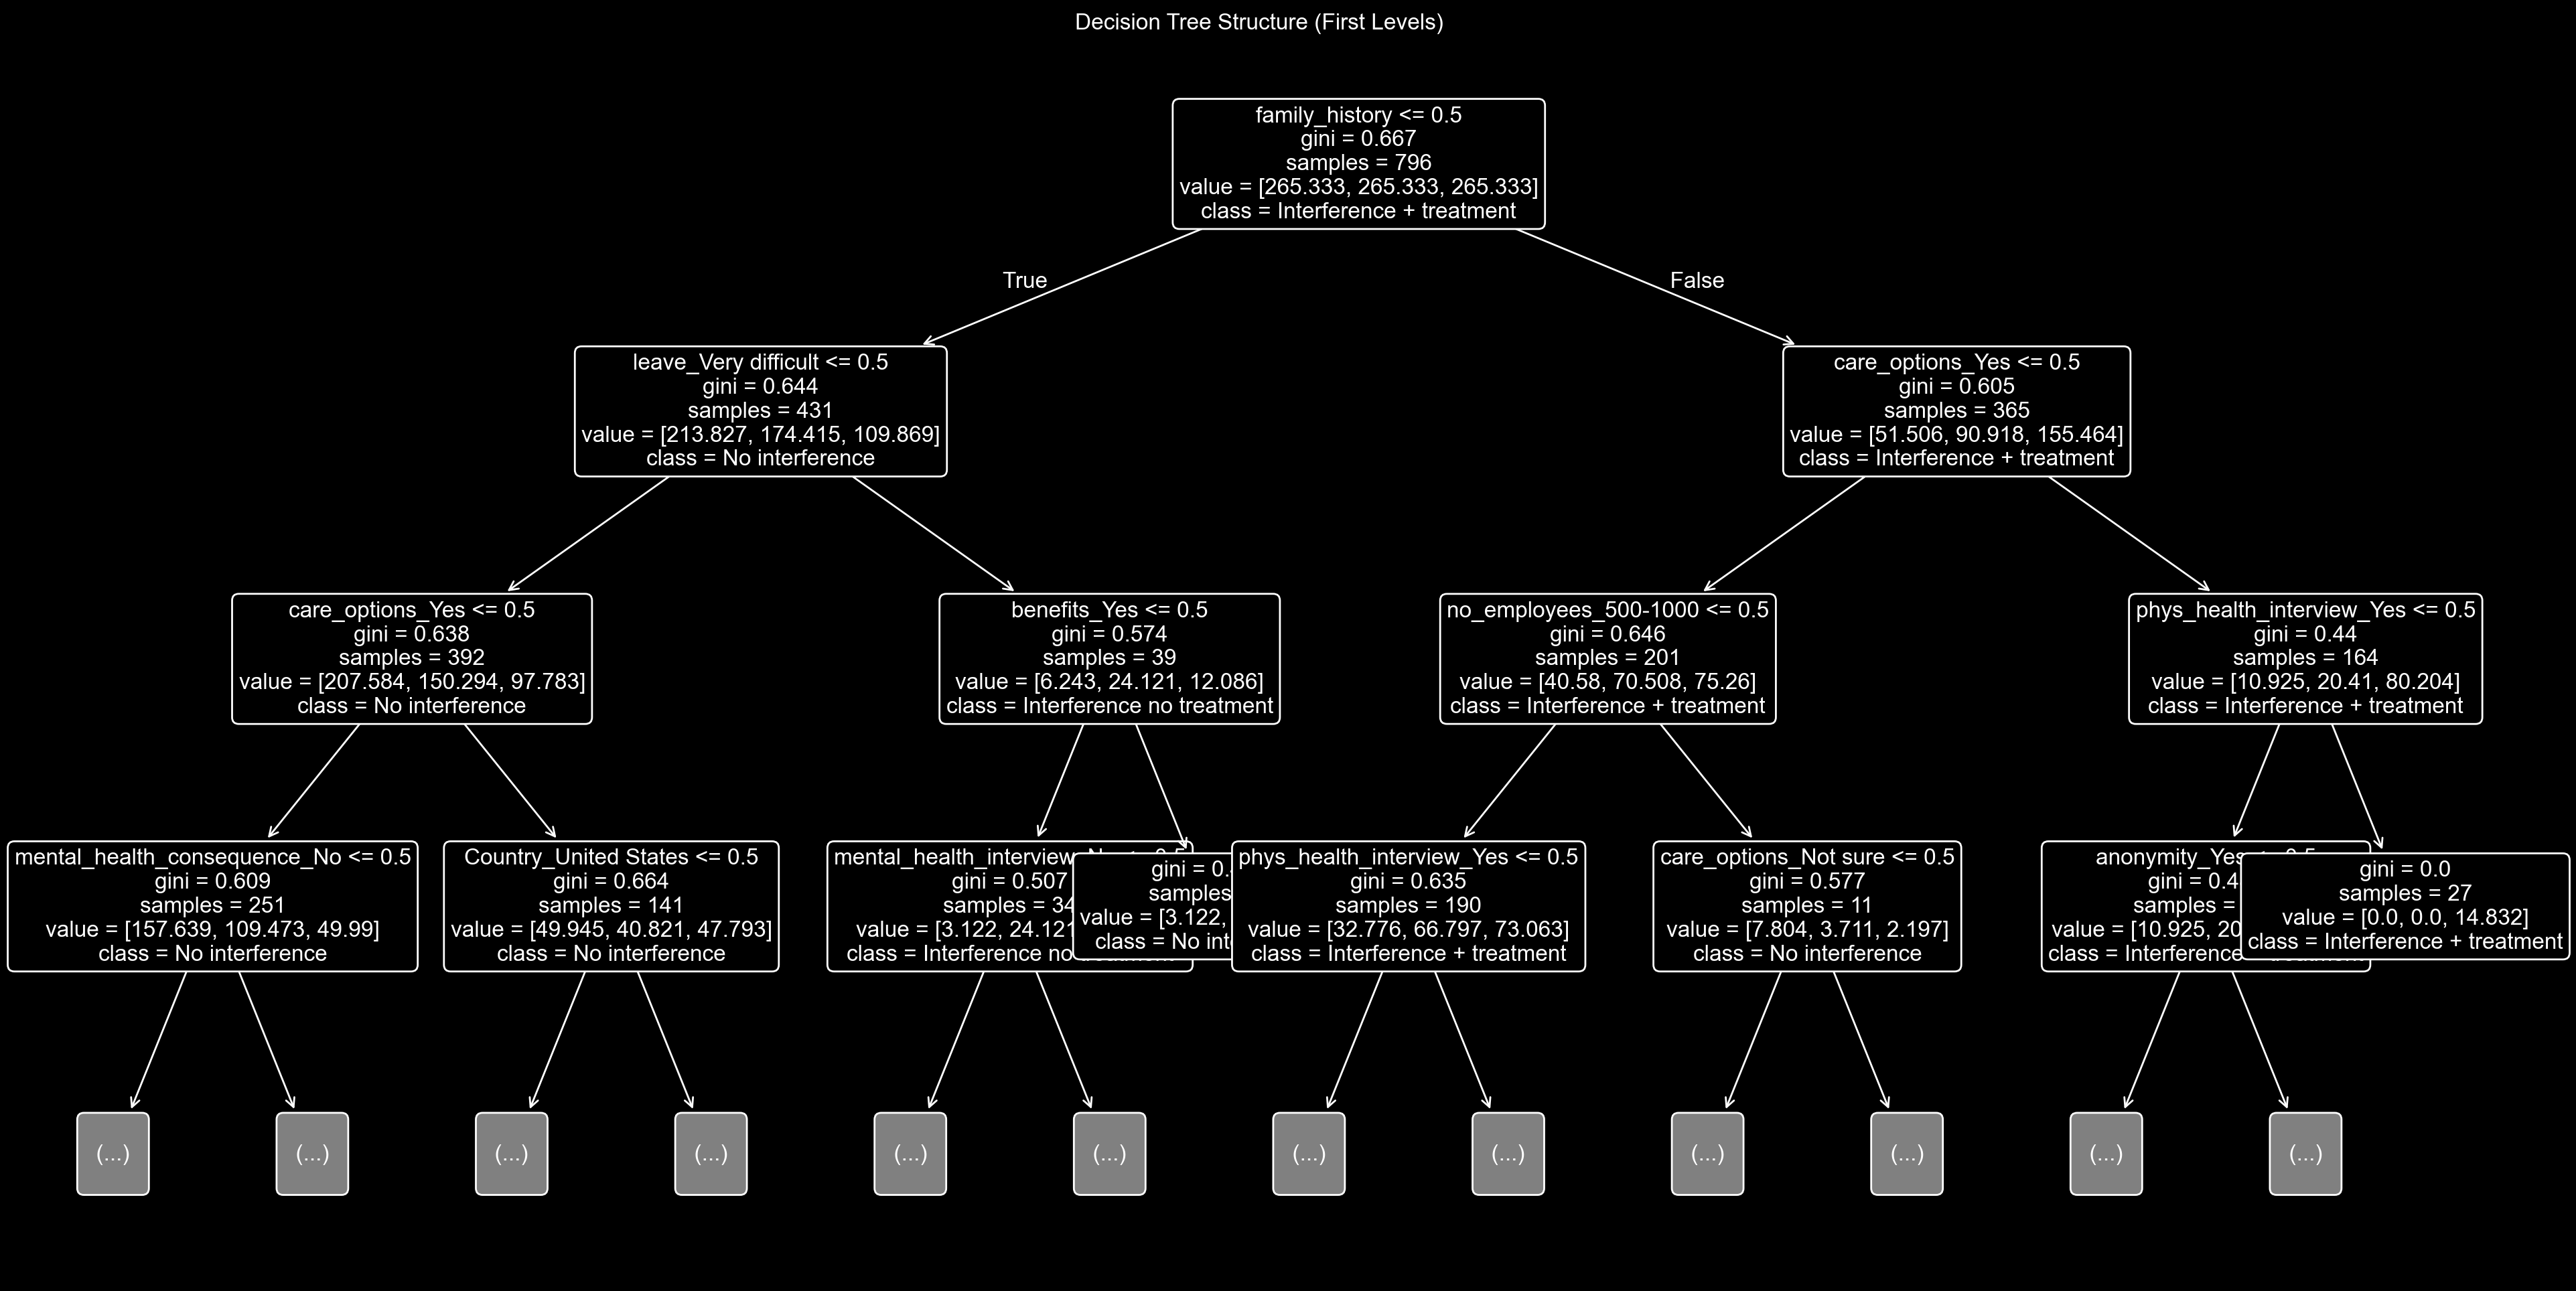

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12), dpi=200)

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No interference","Interference no treatment","Interference + treatment"],
    rounded=True,
    max_depth=3,
    fontsize=12
)

plt.title("Decision Tree Structure (First Levels)")
plt.show()

In [18]:
results = pd.DataFrame([
    {"Model": "Logistic Regression", "Macro F1": macro_f1, "Weighted F1": weighted_f1},
    {"Model": "Decision Tree", "Macro F1": macro_f1_tree, "Weighted F1": weighted_f1_tree},
    {"Model": "Random Forest", "Macro F1": macro_f1_rf, "Weighted F1": weighted_f1_rf},
    {"Model": "XGBoost", "Macro F1": macro_f1_xgb, "Weighted F1": weighted_f1_xgb}
])

print(results)

                 Model  Macro F1  Weighted F1
0  Logistic Regression  0.528081     0.602763
1        Decision Tree  0.421726     0.501429
2        Random Forest  0.495329     0.615635
3              XGBoost  0.467360     0.590889
